# Tech Giants Financial Comparison Tool
## ACC102 Mini Assignment - Track4
**Student**: [张冰冰]
**ID**: [2469540]
**Analytical Purpose**: Compare financial performance of AAPL, MSFT, GOOGL for investors and business students.

## Data Source
- Data: Yahoo Finance (yfinance)
- Companies: AAPL, MSFT, GOOGL
- Indicators: Market Cap, P/E, ROE, Gross Margin, Net Margin, Debt to Equity
- Period: 2018–2023

In [11]:
import yfinance as yf
import pandas as pd
import plotly.express as px

In [12]:
def get_financial_data(ticker):
    stock = yf.Ticker(ticker)
    hist = stock.history(period="max")
    info = stock.info
    metrics = {
        "Market Cap": info.get("marketCap"),
        "P/E": info.get("trailingPE"),
        "ROE": info.get("returnOnEquity"),
        "Gross Margin": info.get("grossMargins"),
        "Net Margin": info.get("profitMargins"),
        "Debt to Equity": info.get("debtToEquity")
    }
    return hist, metrics

In [18]:
companies = ["AAPL", "MSFT", "GOOGL"]
metrics_list = []
data_dict = {}

for company in companies:
    hist, metrics = get_financial_data(company)
    data_dict[company] = hist
    metrics["Company"] = company
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df[["Company", "Market Cap", "P/E", "ROE", "Gross Margin", "Net Margin", "Debt to Equity"]]

metrics_df

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [19]:
fig = px.line()
for company in companies:
    df = data_dict[company]
    df = df[(df.index.year >= 2020) & (df.index.year <= 2023)]
    fig.add_scatter(x=df.index, y=df["Close"], name=company)

fig.update_layout(title="Stock Price Trend 2020-2023", xaxis_title="Date", yaxis_title="Close Price (USD)")
fig.show()

KeyError: 'AAPL'

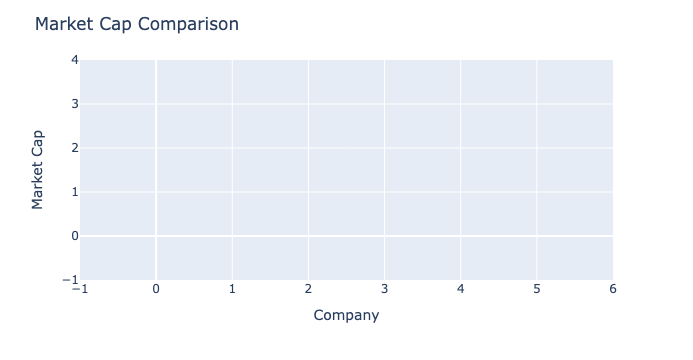

In [14]:
fig2 = px.bar(metrics_df, x="Company", y="Market Cap", color="Company")
fig2.update_layout(title="Market Cap Comparison")
fig2.show()

## Key Insights
1. AAPL has the largest market capitalization among the three companies.
2. MSFT shows strong profitability with high net margin and ROE.
3. GOOGL has a relatively low debt-to-equity ratio, indicating lower financial risk.
4. The tool enables clear comparison for investors and business students.